Goal: compute gradients of D w.r.t. its input.

Tasks:
- Replace BCE with Wasserstein loss: loss_D = D(fake).mean() - D(real).mean() + λ * GP, loss_G = -D(fake).mean().
- No sigmoid on D output (it's a critic, not a classifier).
- Gradient penalty: sample α ~ U(0,1), form interpolates x̂ = α*real + (1-α)*fake, compute ∇_{x̂} D(x̂) with torch.autograd.grad(..., create_graph=True, retain_graph=True), penalize (||∇|| - 1)^2.
- Use Adam β1=0, β2=0.9. Train D 5 steps per G step. λ=10.

Compare: Plot D and G losses against the vanilla GAN from 4a/b. WGAN losses correlate with sample quality; vanilla GAN losses don't.

Concepts: Wasserstein distance, Kantorovich-Rubinstein duality, 1-Lipschitz constraint, gradient penalty.


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
# from torchview import draw_graph

from torchvision import datasets
from torch.utils.data import DataLoader

In [2]:


# Normalize MNIST to [-1, 1] so it matches Tanh output range.
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,0.5, 0.5), std=(0.5,0.5,0.5)),
])
train_ds = datasets.CIFAR10('./cifar', train=True, download=True, transform=transform)
# train_ds.data = train_ds.data[:1600]
train_dl = DataLoader(
    train_ds, batch_size=32, shuffle=True,
    num_workers=2, drop_last=True, pin_memory=True,
)

Files already downloaded and verified


In [3]:
from turtle import forward
from typing import Any
class Generator(nn.Module):
    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        
        self.net = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=100, 
                out_channels=1024, 
                kernel_size=4, 
                # padding=1,
                stride = 1, 
                padding = 0,
            ), # output shape - 1024 x 4 x 4
            nn.BatchNorm2d(1024,momentum=0.5), 
            nn.ReLU(),        
            nn.ConvTranspose2d(
                in_channels=1024, 
                out_channels=512, 
                kernel_size=4, 
                padding=1,
                stride=2, 
            ), # output shape - 512 x 8 x 8
            nn.BatchNorm2d(512,momentum=0.5), 
            nn.ReLU(),        
            nn.ConvTranspose2d(
                in_channels=512, 
                out_channels=256, 
                kernel_size=4, 
                padding=1,
                stride=2, 
            ), # output shape - 256 x 16 x 16
            nn.BatchNorm2d(256,momentum=0.5), 
            nn.ReLU(), 
            # H_OUT = (H_IN - 1) * stride - 2 x padding + dialation x (kernel_size - 1) + output_padding   + 1
            nn.ConvTranspose2d(
                in_channels=256, 
                out_channels=128, 
                kernel_size=4, 
                padding=1,
                stride=2, 
            ), # output shape - 128 x 32 x 32
            nn.BatchNorm2d(128,momentum=0.5), 
            nn.ReLU(),    
            # H_OUT = (H_IN - 1) * stride - 2 x padding + dialation x (kernel_size - 1) + output_padding   + 1
            nn.ConvTranspose2d(
                in_channels=128, 
                out_channels=3, 
                kernel_size=4, 
                padding=1,
                stride=2, 
            ), # output shape - 3 x 64 x 64
            nn.Tanh(),
        )
    def forward(self, x: torch.Tensor):
        # x - [B, N] - n = 100
        # reshape given noise to 100 x 1 x 1
        x = x.unsqueeze(-1).unsqueeze(-1)
        return self.net(x)
    
    
class Discriminator(nn.Module):
    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels=3, 
                out_channels=64,
                kernel_size=4,
                padding=1,
                stride=2, bias=False
            
            ), 
            nn.LayerNorm([64, 32, 32]), 
            nn.LeakyReLU(),
            nn.Conv2d(
                in_channels=64, 
                out_channels=128,
                kernel_size=4,
                padding=1,
                stride=2, bias=False
            
            ), 
            nn.LayerNorm([128, 16, 16]), 
            nn.LeakyReLU(),
            nn.Conv2d(
                in_channels=128, 
                out_channels=256,
                kernel_size=4,
                padding=1,
                stride=2, bias=False
            
            ), 
            nn.LayerNorm([256, 8, 8]), 
            nn.LeakyReLU(),
            nn.Conv2d(
                in_channels=256, 
                out_channels=512,
                kernel_size=4,
                padding=1,
                stride=2, bias=False
            
            ), 
            nn.LayerNorm([512, 4, 4]), 
            nn.LeakyReLU(),
            nn.Conv2d(
                in_channels=512, 
                out_channels=1,
                kernel_size=4,
                padding=0,
                stride=1, bias=False
            )
        )
        
    def forward(self, x: torch.Tensor):
        return self.net(x).view(-1)
    
random_noise = torch.rand([8, 100])
G = Generator()
D = Discriminator()


D(torch.rand([8, 3,64,64]))
# generator_graph = draw_graph(
#     G, 
#     input_size=random_noise.shape, 
#     expand_nested=True
# )
# discriminator_graph = draw_graph(
#     D, 
#     input_size=[8, 3,64,64], 
#     expand_nested=True
# )

tensor([ 0.0247,  0.0239, -0.1405, -0.2475, -0.3388, -0.2285,  0.0697,  0.0937],
       grad_fn=<ViewBackward0>)

In [4]:
# discriminator_graph.visual_graph

In [5]:
# generator_graph.visual_graph

# Training

In [6]:
from tqdm import tqdm
N_EPOCHS, LATENT_DIM = 50, 100
N_CRITIC, LAMBDA_GP = 5, 10.0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

G, D = Generator().to(DEVICE), Discriminator().to(DEVICE)

opt_D = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.0, 0.9))
opt_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))

fixed_z = torch.randn(64, LATENT_DIM, device=DEVICE)

all_losses = []

def gradient_penalty(D, real, fake, device):
    B = real.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)
    x_hat = (alpha * real + (1 - alpha) * fake).requires_grad_(True)

    d_hat = D(x_hat)
    grads = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        grad_outputs=torch.ones_like(d_hat),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grads = grads.view(B, -1)
    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return gp


data_iter = iter(train_dl)
def next_batch():
    global data_iter
    try:    return next(data_iter)
    except StopIteration:
        data_iter = iter(train_dl); return next(data_iter)

for epoch in range(N_EPOCHS):
    epoch_losses = []
    pbar = tqdm(range(len(train_dl) // N_CRITIC), desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    for step in pbar:

        # ---- N_CRITIC critic updates ----
        for _ in range(N_CRITIC):
            real, _ = next_batch()
            real = real.to(DEVICE)
            B = real.size(0)
            z = torch.randn(B, LATENT_DIM, device=DEVICE)
            fake = G(z).detach()

            d_real = D(real)
            d_fake = D(fake)
            gp = gradient_penalty(D, real, fake, DEVICE)
            loss_d = d_fake.mean() - d_real.mean() + LAMBDA_GP * gp

            opt_D.zero_grad(set_to_none=True)
            loss_d.backward()
            opt_D.step()

        # ---- 1 generator update ----
        z = torch.randn(B, LATENT_DIM, device=DEVICE)
        loss_g = -D(G(z)).mean()
        opt_G.zero_grad(set_to_none=True)
        loss_g.backward()
        opt_G.step()
        
        epoch_losses.append([
            loss_g.item(), 
            loss_d.item()
        ])

        if step % 50 == 0:
            w_est = (d_real.mean() - d_fake.mean()).item()
            pbar.set_postfix({
                "W_est": f"{w_est:.3f}",
                "D_loss": f"{loss_d.item():.3f}",
                "G_loss": f"{loss_g.item():.3f}",
                "GP": f"{gp.item():.3f}",
            })

    G.eval()
    with torch.no_grad():
        save_image(G(fixed_z), f'samples_wgan_gp/epoch_{epoch:03d}.png',
                   nrow=8, normalize=True, value_range=(-1, 1))
    G.train()
    
    all_losses.append(epoch_losses)

Epoch 50/50: 100%|██████████| 312/312 [00:22<00:00, 13.84it/s, W_est=1.671, D_loss=-1.403, G_loss=-1.786, GP=0.027]


In [8]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 18.0 MB/s  0:00:00eta 0:00:01
Using cached contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (355 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 37.0 MB/s  0:00:00
Using cached kiwisolver-1.5.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.4 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


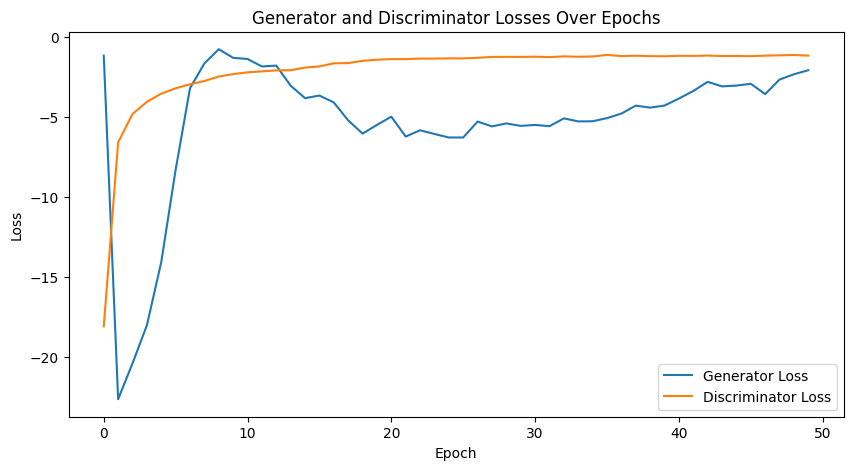

In [10]:
from matplotlib import pyplot as plt

# Plot generator and discriminator losses per epoch
g_losses = [sum([step[0] for step in epoch]) / len(epoch) for epoch in all_losses]
d_losses = [sum([step[1] for step in epoch]) / len(epoch) for epoch in all_losses]

plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Losses Over Epochs")
plt.legend()
plt.show()

References:
 - Radford et al. 2016: Unsupervised Representation Learning with DCGANs — Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks
 - PyTorch DCGAN tutorial (reference implementation): DCGAN Tutorial — PyTorch Tutorials 2.12.0+cu130 documentation